In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from matplotlib.colors import ListedColormap

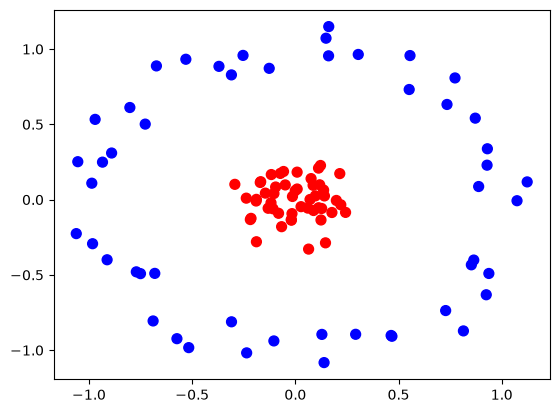

In [16]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [20]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score
acccuracy_score = (y_test, y_pred)

In [28]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

C:\Users\anike\AppData\Local\Temp\ipykernel_15904\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


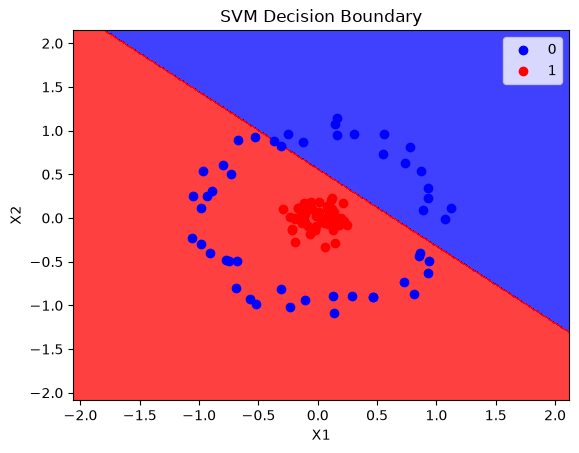

In [29]:
plot_decision_boundary(X, y, classifier)

In [30]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

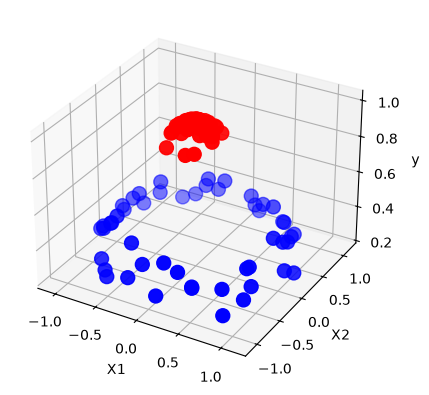

In [31]:
plot_3d_plot(X,y)

In [32]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [33]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\anike\AppData\Local\Temp\ipykernel_15904\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


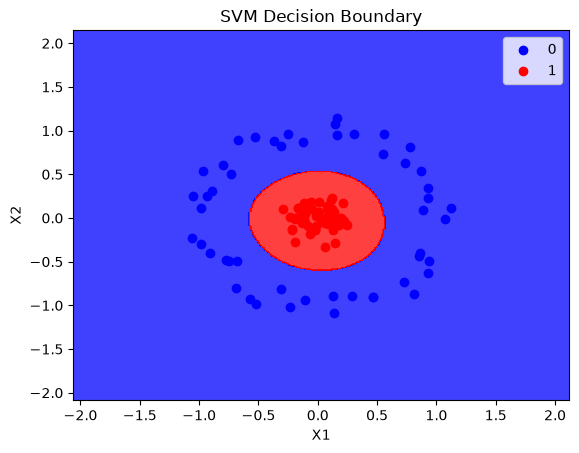

In [34]:
plot_decision_boundary(X, y, rbf_classifier)

In [35]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [36]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\anike\AppData\Local\Temp\ipykernel_15904\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


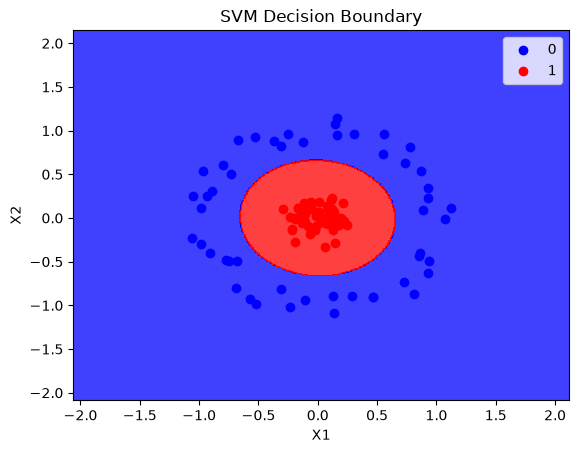

In [37]:
plot_decision_boundary(X, y, poly_classifier)

In [38]:
X

array([[-1.31718400e-01, -5.73643637e-02],
       [-2.14612953e-01, -1.24405750e-01],
       [ 2.43388599e-01, -8.47656473e-02],
       [ 1.21931028e-01,  2.26826560e-01],
       [ 8.14332416e-01, -8.71945565e-01],
       [-9.11887379e-01, -3.99390835e-01],
       [ 7.73592256e-01,  8.08199421e-01],
       [-1.17911474e-01, -2.10231265e-02],
       [-7.27247979e-01,  5.01516940e-01],
       [-1.05392855e+00,  2.51928383e-01],
       [ 1.61051064e-01,  9.55050151e-01],
       [-9.54292043e-02,  8.37677493e-02],
       [ 8.82331906e-02, -7.22791736e-02],
       [-1.89932849e-01, -9.13869077e-03],
       [ 1.24243151e-01, -1.35211418e-01],
       [ 8.93897870e-03,  7.05226017e-02],
       [-1.88513234e-01, -2.79783100e-01],
       [ 1.39250981e-01, -1.08232862e+00],
       [ 1.61910826e-01,  1.14924190e+00],
       [ 8.52785525e-01, -4.32970722e-01],
       [ 2.15347802e-01,  1.72831255e-01],
       [ 7.11682089e-02,  8.45003163e-04],
       [-6.89030211e-01, -8.05804863e-01],
       [ 2.

In [39]:
np.exp(-(X**2)).sum(1)

array([1.97951464, 1.93962824, 1.93532296, 1.93509366, 0.98276363,
       1.28793775, 1.07005074, 1.98575121, 1.3668774 , 1.26781105,
       1.3760675 , 1.98394213, 1.98703447, 1.96448493, 1.96656615,
       1.99495901, 1.88979358, 1.29071777, 1.24105869, 1.31229863,
       1.92525527, 1.99494718, 1.14443281, 1.95144266, 1.9638007 ,
       1.98468157, 1.41200505, 1.98357221, 1.9821766 , 1.26941355,
       1.9881343 , 1.98038001, 1.16946654, 1.36639362, 1.30595323,
       1.98996888, 1.31290575, 1.31546713, 1.90745291, 1.13472062,
       1.27450781, 1.14301712, 1.97729934, 1.99316531, 1.95917098,
       1.99111717, 1.40371614, 1.98765696, 1.17407233, 1.36745534,
       1.24216724, 1.37097834, 1.98447472, 1.97488956, 1.20139846,
       1.89352612, 1.300864  , 1.34688765, 1.98111258, 1.9765141 ,
       1.962409  , 1.35500133, 1.96487137, 1.89979875, 1.32888634,
       1.42643889, 1.96124122, 1.33729066, 1.4467826 , 1.99936826,
       1.4323488 , 1.45165195, 1.14574684, 1.99646256, 1.32485

In [40]:
X_new=np.exp(-(X**2))

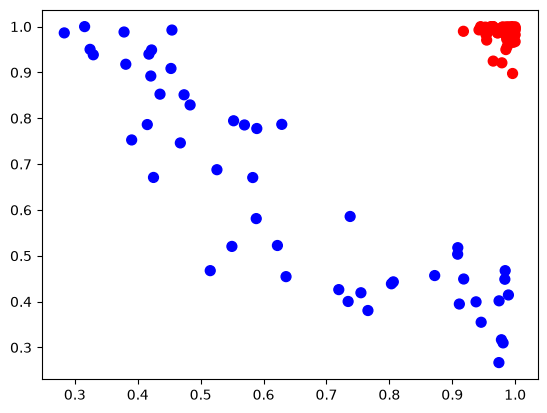

In [41]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')